In [8]:
import akshare as ak
import pandas as pd
from tqdm import tqdm
import os
import time
import socket

# 设置全局 timeout 防止网络请求卡死
socket.setdefaulttimeout(15)

# 示例: 读取HSCI成分股(需确保此时你已有股票代码的列表)
# 这里假设成分股代码已读取为一个list，如 hk_stocks = ["00700", "00981", ...]
hk_stocks = ["00700", "00005"]  # 占位符，演示用。你可以替换成你实际的HSCI名单
# ③ 股票池 (HSCI) - 按每一期成分股处理
hsci = pd.read_csv("data/HSCI.csv")
hsci["date"] = pd.to_datetime(hsci["date"])
hsci["is_hsci"] = 1

# 自动识别股票代码列
code_col = next((c for c in ["sid", "stock_code", "symbol", "code"] if c in hsci.columns), None)
if code_col is None:
    raise ValueError("HSCI.csv 中未找到股票代码列，请包含 sid/stock_code/symbol/code 之一")

# 标准化代码 + 仅保留成分股 (去除可能存在的 .HK 后缀并补齐5位)
hsci[code_col] = hsci[code_col].astype(str).str.replace(".HK", "", regex=False).str.zfill(5)
hsci = hsci.loc[hsci["is_hsci"] == 1, ["date", code_col]].dropna().copy()

# 每一期(按月)成分股列表
hsci["date_m"] = hsci["date"].dt.to_period("M")
hsci_period_stocks = (
    hsci.groupby("date_m")[code_col]
    .apply(lambda s: sorted(s.unique().tolist()))
    .to_dict()
)

# 下载层面：取全样本所有出现过的股票，避免重复请求同一股票历史数据
hk_stocks = sorted({sid for sids in hsci_period_stocks.values() for sid in sids})

print(f"HSCI periods: {len(hsci_period_stocks)}, unique stocks to fetch: {len(hk_stocks)}")

bm_data_list = []

for stock_code in tqdm(hk_stocks, desc="Fetching PB data"):
    try:
        # 获取市净率(PB)
        # 加入简单的重试机制
        for _ in range(3):
            try:
                df_pb = ak.stock_hk_valuation_baidu(symbol=stock_code, indicator="市净率", period="全部")
                break
            except Exception as inner_e:
                time.sleep(1)
        else:
            raise Exception("Retry limit reached")
            
        if df_pb is not None and not df_pb.empty:
            df_pb.rename(columns={"date": "trade_date", "value": "PB"}, inplace=True)
            
            # 计算账面市值比 (BM = 1 / PB)
            df_pb["BM"] = 1 / df_pb["PB"]
            df_pb["stock_code"] = stock_code
            
            bm_data_list.append(df_pb)
    except Exception as e:
        # 异常不中断，直接打印，防止部分股票退市等原因报错
        pass

# 拼接所有数据并抽取为月度频率保存
if bm_data_list:
    df_bm_all = pd.concat(bm_data_list, ignore_index=True)
    df_bm_all["trade_date"] = pd.to_datetime(df_bm_all["trade_date"])
    
    # 提取按月分组字段，并对数据按时间排序，取每只个股每个月的最后一条有效数据作为当月数据
    df_bm_all['date_m'] = df_bm_all['trade_date'].dt.to_period('M')
    df_bm_monthly = df_bm_all.sort_values('trade_date').groupby(['stock_code', 'date_m']).last().reset_index()
    
    # 重命名列以尽量对齐回测习惯 (trade_date 变成最后交易日 date, stock_code 变为 sid)
    df_bm_monthly.rename(columns={"trade_date": "date", "stock_code": "sid"}, inplace=True)
    
    print("获取到的月度BM数据样例：")
    print(df_bm_monthly.tail())
    
    # 保存到 data 文件夹里面
    if not os.path.exists("data"):
        os.makedirs("data")
        
    out_path = "data/hk_bm_monthly.csv"
    df_bm_monthly.to_csv(out_path, index=False)
    print(f"\n数据已成功去重降频为月度(月末)，并保存至 {out_path}")
else:
    print("未获取到任何数据")

HSCI periods: 252, unique stocks to fetch: 1126


Fetching PB data: 100%|██████████| 1126/1126 [05:16<00:00,  3.55it/s]


获取到的月度BM数据样例：
          sid   date_m       date    PB        BM
189458  09999  2025-11 2025-11-29  3.96  0.252525
189459  09999  2025-12 2025-12-31  3.97  0.251889
189460  09999  2026-01 2026-01-30  3.79  0.263852
189461  09999  2026-02 2026-02-27  3.20  0.312500
189462  09999  2026-03 2026-03-25  3.15  0.317460

数据已成功去重降频为月度(月末)，并保存至 data/hk_bm_monthly.csv


In [3]:
import pandas as pd
import numpy as np
import akshare as ak
import warnings
warnings.filterwarnings('ignore')

print("Loading data for Fama-French 3-Factor calculation...")

# ================= 1. 加载和预处理数据 =================

# 1) 价格与收益率数据
price_cols = pd.read_csv('data/hk_price.csv', usecols=['date', 'sid', 'close', 'AdjClose'])
price_cols['date'] = pd.to_datetime(price_cols['date'])
price_cols['date_m'] = price_cols['date'].dt.to_period('M')

# 计算每月末的复权价及下月收益率
monthly_price = price_cols.sort_values('date').groupby(['date_m', 'sid']).last().reset_index()
monthly_price_pivot = monthly_price.pivot(index='date_m', columns='sid', values='AdjClose')
# 计算各股票的当月收益率（以期末对齐，即t月末的收益是t月份内的收益率，或者我们计算其下月收益以t期截面做加权）
# 因子计算通常是：在t月末，基于t月末的市值和BM进行分组，持有到t+1月末，计算t+1月的组合收益。
# 所以这里算出t月末到t+1月末的收益率，对齐在t月上，作为“下月收益率”。
monthly_ret = monthly_price_pivot.pct_change(fill_method=None).shift(-1).unstack().reset_index()
monthly_ret.columns = ['sid', 'date_m', 'next_ret']

# 2) 市值数据 (Size)
with pd.HDFStore('data/hk_shares.h5') as store:
    shares = store.get(store.keys()[0]).reset_index()
shares['sid'] = shares['order_book_id'].str[1:5] + '.HK'
shares['date_m'] = pd.to_datetime(shares['date']).dt.to_period('M')
shares_monthly = shares.sort_values('date').groupby(['date_m', 'sid']).last().reset_index()

mcap_df = pd.merge(monthly_price[['date_m', 'sid', 'close']], 
                   shares_monthly[['date_m', 'sid', 'total']], 
                   on=['date_m', 'sid'], how='inner')
mcap_df['mcap'] = mcap_df['close'] * mcap_df['total'] # 总市值

# 3) BM数据 (Value)
# 假设上面的代码已生成 hk_bm_monthly.csv，如果不存在请先运行上一个 Cell 获取数据
# 这里的sid可能是 "00700" 格式，需要转为 "0700.HK" 一直的格式
try:
    bm_df = pd.read_csv('data/hk_bm_monthly.csv')
    bm_df['date'] = pd.to_datetime(bm_df['date'])
    bm_df['date_m'] = bm_df['date'].dt.to_period('M')
    bm_df['sid'] = bm_df['sid'].astype(str).str.zfill(4) + '.HK'
except FileNotFoundError:
    print("未找到 hk_bm_monthly.csv，请先确保获取了账面市值比数据。")
    bm_df = pd.DataFrame(columns=['date_m', 'sid', 'BM'])

# 4) 获取无风险利率 Rf (使用 akshare 获取中美十年期国债收益率的中国10年期作为代理)
print("Fetching Risk-Free Rate (Rf) from akshare...")
try:
    rf_data = ak.bond_zh_us_rate()
    rf_data['date'] = pd.to_datetime(rf_data['日期'])
    rf_data['date_m'] = rf_data['date'].dt.to_period('M')
    # 取这一个月最后一条有效数据，转成月度无风险收益率 = 年化收益率(%) / 100 / 12
    rf_monthly = rf_data.sort_values('date').groupby('date_m').last().reset_index()
    rf_monthly['Rf'] = rf_monthly['中国国债收益率10年'] / 100 / 12
    
    # 保存无风险利率数据以备他用(如回测等)
    rf_out_path = 'data/hk_risk_free_rate.csv'
    rf_monthly[['date_m', 'Rf']].to_csv(rf_out_path, index=False)
    print(f"Risk-Free Rate saved to {rf_out_path}")
    
except Exception as e:
    print(f"Failed to fetch Rf: {e}, using 0.0 as fallback.")
    rf_monthly = pd.DataFrame(columns=['date_m', 'Rf'])

# 5) 合并横截面数据 (每月末的 mcap, BM，及其对应的 next_ret, 还有 Rf)
ff_data = pd.merge(mcap_df[['date_m', 'sid', 'mcap']], bm_df[['date_m', 'sid', 'BM']], on=['date_m', 'sid'], how='inner')
ff_data = pd.merge(ff_data, monthly_ret, on=['date_m', 'sid'], how='inner')

if not rf_monthly.empty:
    ff_data = pd.merge(ff_data, rf_monthly[['date_m', 'Rf']], on='date_m', how='left')
    ff_data['Rf'] = ff_data['Rf'].fillna(0.0) # 防止部分极端月份缺失
else:
    ff_data['Rf'] = 0.0

# 剔除可能存在的无穷大溢出值 (由于前期价格为0等异常情况截断引起的pct_change变成inf)
ff_data.replace([np.inf, -np.inf], np.nan, inplace=True)
ff_data = ff_data.dropna(subset=['mcap', 'BM', 'next_ret'])

# ================= 2. 截面分组 (2x3组) =================
# 在每个月底(date_m)，按市值中位数分为 Small(S) 和 Big(B)，
# 按BM的30%和70%分位数分为 Low(L), Medium(M), High(H)。
def calc_ff_factors(df):
    if len(df) < 10: # 样本量太少跳过
        return pd.Series({'MKT': np.nan, 'SMB': np.nan, 'HML': np.nan})
    
    # 获取分组断点
    size_median = df['mcap'].median()
    bm_30 = df['BM'].quantile(0.3)
    bm_70 = df['BM'].quantile(0.7)
    
    # 划分Size组别: S (Small), B (Big)
    df['Size_Port'] = np.where(df['mcap'] <= size_median, 'S', 'B')
    
    # 划分BM组别: L (Low), M (Medium), H (High)
    df['BM_Port'] = np.where(df['BM'] <= bm_30, 'L', np.where(df['BM'] > bm_70, 'H', 'M'))
    
    # 计算6个组合的市值加权收益率
    # 这里我们是对下个月的收益率 next_ret 进行市值加权
    group_mcap = df.groupby(['Size_Port', 'BM_Port'])['mcap'].transform('sum')
    df['weight'] = np.where(group_mcap > 0, df['mcap'] / group_mcap, 0.0)
    port_rets = df.groupby(['Size_Port', 'BM_Port']).apply(lambda x: (x['next_ret'] * x['weight']).sum())
    
    # 如果有的组缺失，给个默认值（防止报错）
    for s in ['S', 'B']:
        for b in ['L', 'M', 'H']:
            if (s, b) not in port_rets.index:
                port_rets[(s, b)] = 0.0
                
    # SMB = 1/3 * (SL + SM + SH) - 1/3 * (BL + BM + BH)
    smb = (port_rets[('S', 'L')] + port_rets[('S', 'M')] + port_rets[('S', 'H')]) / 3 - \
          (port_rets[('B', 'L')] + port_rets[('B', 'M')] + port_rets[('B', 'H')]) / 3
          
    # HML = 1/2 * (SH + BH) - 1/2 * (SL + BL)
    hml = (port_rets[('S', 'H')] + port_rets[('B', 'H')]) / 2 - \
          (port_rets[('S', 'L')] + port_rets[('B', 'L')]) / 2
          
    # MKT 市场收益率 (减去无风险利率 Rf)
    # 所有股票的市值加权
    mkt_mcap_sum = df['mcap'].sum()
    mkt_weight = df['mcap'] / mkt_mcap_sum if mkt_mcap_sum > 0 else 0.0
    rf_val = df['Rf'].iloc[0] if 'Rf' in df.columns else 0.0
    mkt = (df['next_ret'] * mkt_weight).sum() - rf_val
    
    return pd.Series({'MKT': mkt, 'SMB': smb, 'HML': hml})

print("Calculating Fama-French 3 Factors...")
ff_factors_next = ff_data.groupby('date_m').apply(calc_ff_factors).reset_index()

# ff_factors_next中的因子收益实际上是该期末对下个月的回报(t到t+1)
# 我们将日期平移到下月(t+1)，表示t+1月的因子收益率
ff_factors_next['date_m'] = ff_factors_next['date_m'] + 1
ff_factors = ff_factors_next.dropna()

print(ff_factors.tail())

# 保存 Fama-French 3-Factor 数据
ff_factors.to_csv('data/hk_ff3_factors.csv', index=False)
print("FF3 数据已保存至 data/hk_ff3_factors.csv")


Loading data for Fama-French 3-Factor calculation...
Fetching Risk-Free Rate (Rf) from akshare...


  0%|          | 0/19 [00:00<?, ?it/s]

Risk-Free Rate saved to data/hk_risk_free_rate.csv
Calculating Fama-French 3 Factors...
      date_m       MKT       SMB       HML
183  2025-05  0.062533  0.016028 -0.030673
184  2025-06  0.053154  0.006182  0.060066
185  2025-07  0.056438  0.046500 -0.013104
186  2025-08  0.031711  0.025986 -0.033110
187  2025-09  0.057714 -0.029195 -0.046799
FF3 数据已保存至 data/hk_ff3_factors.csv


In [ ]:
# 这里假设成分股代码已读取为一个list，如 hk_stocks = ["00700", "00981", ...]
import pandas as pd
import matplotlib.pyplot as plt

hk_stocks = ["00700", "00005"]  # 占位符，演示用。你可以替换成你实际的HSCI名单
# ③ 股票池 (HSCI) - 按每一期成分股处理
hsci = pd.read_csv("data/HSCI.csv")
hsci["date"] = pd.to_datetime(hsci["date"])
hsci["is_hsci"] = 1


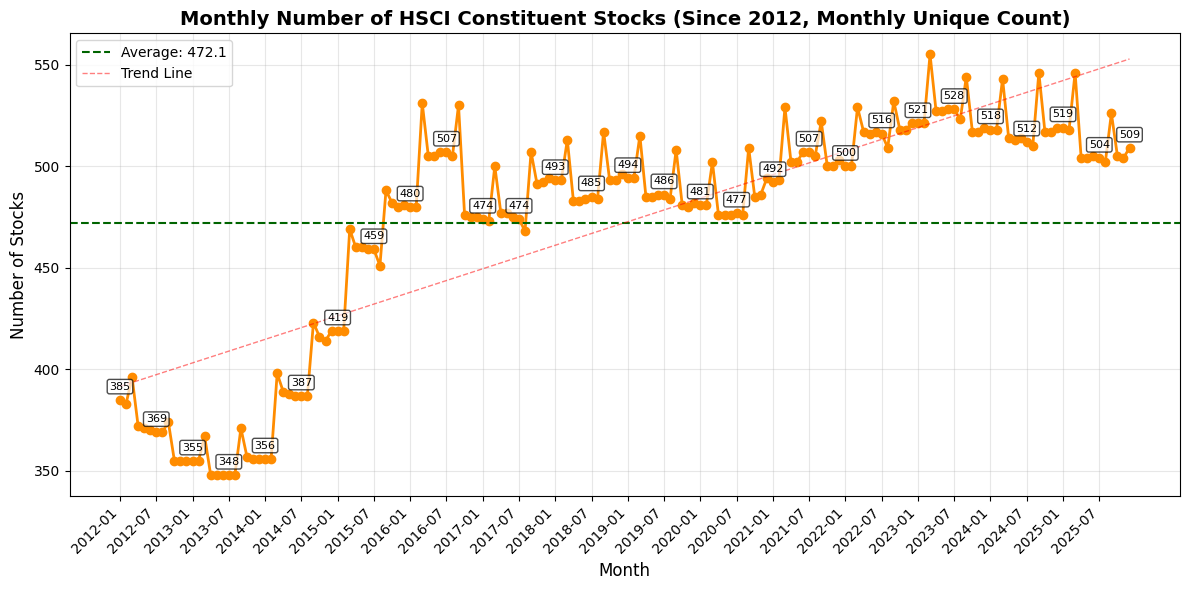


HSCI成分股统计信息（2012年以后，按月去重统计）：
总时间区间: 2012-01 到 2025-12
月份数量: 168
平均成分股数量: 472.1
最小成分股数量: 348 (月份: 2013-04)
最大成分股数量: 555 (月份: 2023-03)

年份统计（每年1月数据）：
2012年1月: 385 只股票
2013年1月: 355 只股票
2014年1月: 356 只股票
2015年1月: 419 只股票
2016年1月: 480 只股票
2017年1月: 474 只股票
2018年1月: 493 只股票
2019年1月: 494 只股票
2020年1月: 481 只股票
2021年1月: 492 只股票
2022年1月: 500 只股票
2023年1月: 521 只股票
2024年1月: 518 只股票
2025年1月: 519 只股票

月度统计（最近12个月）：
2025-01: 519 只股票
2025-02: 518 只股票
2025-03: 546 只股票
2025-04: 504 只股票
2025-05: 504 只股票
2025-06: 505 只股票
2025-07: 504 只股票
2025-08: 502 只股票
2025-09: 526 只股票
2025-10: 505 只股票
2025-11: 504 只股票
2025-12: 509 只股票


In [11]:
# 绘制HSCI成分股数量趋势图（2012年以后，按月去重统计）
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 确保date列是datetime类型
hsci['date'] = pd.to_datetime(hsci['date'])

# 筛选2012年1月及之后的数据
hsci_filtered = hsci[hsci['date'] >= '2012-01-01'].copy()

# 创建年月列
hsci_filtered['year_month'] = hsci_filtered['date'].dt.to_period('M')

# 按月对股票代码去重，统计每月总的成分股数量
monthly_unique_stocks = hsci_filtered.groupby('year_month')['sid'].nunique()

# 转换为列表格式用于绘图
months_hsci = [str(month) for month in monthly_unique_stocks.index]
counts_hsci = monthly_unique_stocks.values.tolist()

# 创建图表
plt.figure(figsize=(12, 6))
plt.plot(months_hsci, counts_hsci, marker='o', linestyle='-', linewidth=2, color='darkorange')
plt.title('Monthly Number of HSCI Constituent Stocks (Since 2012, Monthly Unique Count)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Stocks', fontsize=12)

# 设置x轴刻度：每6个月显示一次标签
if len(months_hsci) >= 6:
    tick_positions = list(range(0, len(months_hsci), 6))
    tick_labels = [months_hsci[i] for i in tick_positions]
    plt.xticks(tick_positions, tick_labels, rotation=45, ha='right')
else:
    plt.xticks(range(len(months_hsci)), months_hsci, rotation=45, ha='right')
    
plt.grid(True, alpha=0.3)
plt.tight_layout()

# 添加平均线
avg_hsci = np.mean(counts_hsci) if counts_hsci else 0
plt.axhline(y=avg_hsci, color='darkgreen', linestyle='--', linewidth=1.5, 
           label=f'Average: {avg_hsci:.1f}')

# 添加数据点标签 - 每6个月显示一次
for i, (month, count) in enumerate(zip(months_hsci, counts_hsci)):
    if i % 6 == 0 or i == len(months_hsci)-1:
        plt.text(i, count+5, str(count), ha='center', fontsize=8, 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# 添加趋势线
if len(counts_hsci) > 1:
    z = np.polyfit(range(len(counts_hsci)), counts_hsci, 1)
    p = np.poly1d(z)
    plt.plot(months_hsci, p(range(len(counts_hsci))), "r--", alpha=0.5, 
             label='Trend Line', linewidth=1)

plt.legend()
plt.show()

# 打印统计信息
print(f"\nHSCI成分股统计信息（2012年以后，按月去重统计）：")
print(f"总时间区间: {months_hsci[0]} 到 {months_hsci[-1]}")
print(f"月份数量: {len(months_hsci)}")
print(f"平均成分股数量: {avg_hsci:.1f}")
print(f"最小成分股数量: {min(counts_hsci)} (月份: {months_hsci[counts_hsci.index(min(counts_hsci))]})")
print(f"最大成分股数量: {max(counts_hsci)} (月份: {months_hsci[counts_hsci.index(max(counts_hsci))]})")

# 查看每年的数据变化
print(f"\n年份统计（每年1月数据）：")
year_stats = {}
for i, month in enumerate(months_hsci):
    if month.endswith('-01'):
        year = month[:4]
        if int(year) >= 2012:
            year_stats[year] = counts_hsci[i]

for year, count in sorted(year_stats.items()):
    print(f"{year}年1月: {count} 只股票")

# 额外的月度统计
print(f"\n月度统计（最近12个月）：")
if len(months_hsci) >= 12:
    recent_months = months_hsci[-12:]
    recent_counts = counts_hsci[-12:]
    for month, count in zip(recent_months, recent_counts):
        print(f"{month}: {count} 只股票")
else:
    for month, count in zip(months_hsci, counts_hsci):
        print(f"{month}: {count} 只股票")